# MrScraper Price Intelligence — Results Summary

Comparison of **Tier 1 (Global Marketplace Model)** vs **Tier 2 (Shop/Product-level Model)**, plus the anchor-set calibration study, on a leakage-safe 5-day outage backtest.

All numbers are produced by the scripts in `src/`; this notebook just loads and visualizes the saved reports. Run the pipeline first (`make backtest tier1 calib tier2 results`).

In [1]:
import json
from pathlib import Path
import pandas as pd

REPORTS = Path('..') / 'reports'
def load(name):
    p = REPORTS / name
    return json.loads(p.read_text()) if p.exists() else None

## 1. Model leaderboard (5-day outage backtest)

In [2]:
rows = []
def add(name, tier, res):
    o = res['overall']
    rows.append({'model': name, 'tier': tier, 'MAPE_%': o['mape'],
                 'sMAPE_%': o['smape'], 'MedAPE_%': o['medape'],
                 'MAE_IDR': o['mae'], 'RMSE_IDR': o['rmse'],
                 'R2': o['r2'], 'n': o['n']})

t1 = load('tier1_backtest.json')
if t1:
    add('LOCF (last price)', 'baseline', t1['locf'])
    add('Tier1 Global CatBoost', 'tier1', t1['global_catboost'])
    if 'gated' in t1:
        add('Tier1 Gated (LOCF+CatBoost)', 'tier1', t1['gated'])
    if 'cb_global_cal' in t1:
        add('Tier1 CatBoost + global anchor cal', 'tier1', t1['cb_global_cal'])
    if 'cb_category_cal' in t1:
        add('Tier1 CatBoost + per-category anchor cal', 'tier1', t1['cb_category_cal'])

t2 = load('tier2_backtest.json')
if t2:
    add('Tier2 Hierarchical fallback', 'tier2', t2['hier'])
    add('Tier2 Robust recent-K median', 'tier2', t2['robust_recent'])
    add('Tier2 Hier + global anchor cal', 'tier2', t2['cal_global'])
    add('Tier2 Hier + per-category anchor cal', 'tier2', t2['cal_category'])


lb = pd.DataFrame(rows).drop_duplicates('model').sort_values('MAPE_%').reset_index(drop=True)
lb


,model,tier,MAPE_%,sMAPE_%,MedAPE_%,MAE_IDR,RMSE_IDR,R2,n
0,Tier2 Hier + per-category anchor cal,tier2,0.8286,0.4082,0.0000,241665.99,8033049.06,0.990693,40055
1,LOCF (last price),baseline,0.9385,0.4170,0.0000,247996.50,8067210.85,0.990614,40055
2,Tier2 Hierarchical fallback,tier2,0.9385,0.4170,0.0000,247996.50,8067210.85,0.990614,40055
3,Tier2 Hier + global anchor cal,tier2,0.9385,0.4170,0.0000,247996.50,8067210.85,0.990614,40055
4,Tier2 Robust recent-K median,tier2,1.0953,0.5549,0.0000,350932.47,8143065.08,0.990437,40055
5,Tier1 Gated (LOCF+CatBoost),tier1,1.7124,0.4881,0.0000,338766.48,8768850.26,0.988910,40055
6,Tier1 CatBoost + per-category anchor cal,tier1,1.8241,0.6841,0.0977,403791.06,8721888.10,0.989029,40055
7,Tier1 CatBoost + global anchor cal,tier1,1.9206,0.6986,0.1027,412449.02,8776903.17,0.988890,40055
8,Tier1 Global CatBoost,tier1,1.9369,0.7148,0.1240,416193.36,8775076.54,0.988895,40055


**Takeaways.** Price is near-deterministic per `modelId` (83% of modelIds never change price), so LOCF is a very strong baseline. Tier 1 CatBoost is now trained with strict pre-day entity statistics, removing the earlier within-fold look-ahead issue. Its best leak-safe variant is **Tier1 Gated (LOCF+CatBoost)** at 1.7124% MAPE, while **Tier 2 hierarchical LOCF + per-category anchor calibration** still wins at 0.8286% MAPE. The CatBoost variants underperform because they smooth the flat majority.

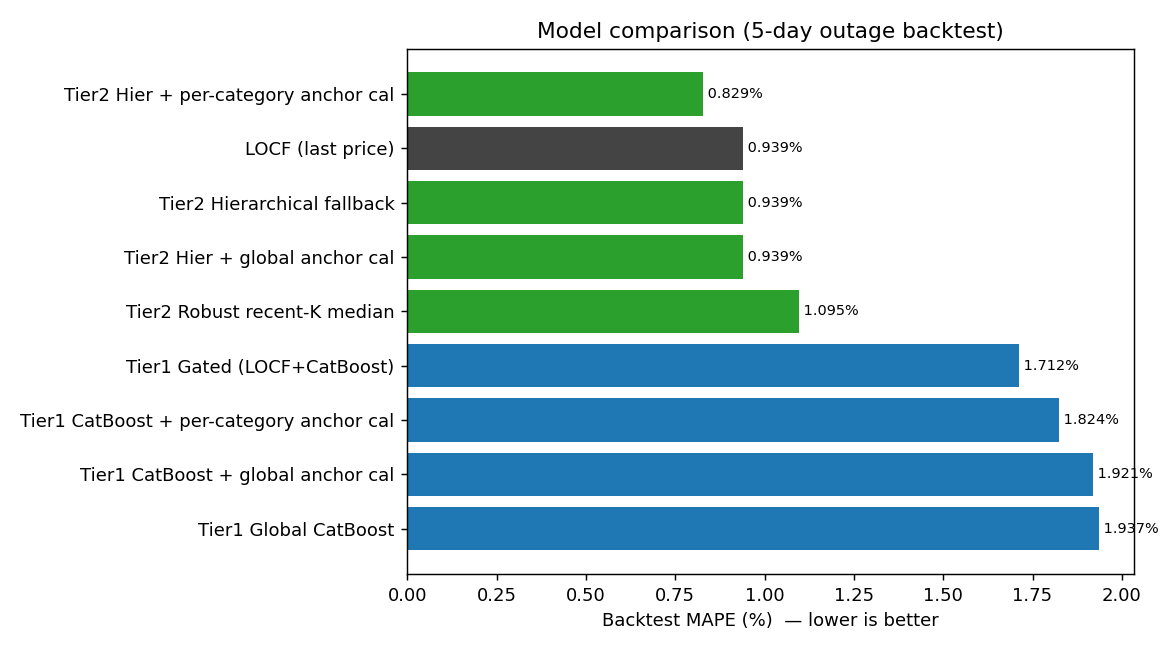

In [3]:
from IPython.display import Image
Image(str(REPORTS / 'fig_model_comparison.png'))

## 2. Per-day detail (where does signal live?)

In [4]:
locf = pd.DataFrame(t1['locf']['per_day']).set_index('day')[['mape','mae']]
calc = pd.DataFrame(t2['cal_category']['per_day']).set_index('day')[['mape','mae']]
cmp = locf.join(calc, lsuffix='_LOCF', rsuffix='_PerCatCal')
cmp

,mape_LOCF,mae_LOCF,mape_PerCatCal,mae_PerCatCal
day,,,,
2025-03-18,0.4069,230411.26,0.4069,230411.26
2025-03-19,0.3138,508714.41,0.3138,508714.41
2025-03-20,0.0889,50107.69,0.0889,50107.69
2025-03-21,3.7472,309817.72,3.1941,277942.32
2025-03-22,0.0072,3081.12,0.0072,3081.12


The gain from calibration concentrates on the volatile day (2025-03-21), where per-category calibration cuts MAPE from ~3.75% to ~3.19%. On flat days both are identical — calibration is harmless when there is no drift.

## 3. Anchor-set calibration — synthetic-shift stress test

The 3 shared days have ~0 real drift, so to prove the anchors actually correct day-level shifts we inject a known +15% platform-wide shift (plus +10% on half the categories) on a held-out day and recover it from the 100 anchors.

In [5]:
cal = load('calibration.json')
syn = cal['synthetic_shift']
print('recovered global factor:', round(syn['recovered_global_factor'], 4),
      '(injected', syn['injected_global_shift'], ')')
pd.DataFrame({s: cal['synthetic_shift']['results'][s] for s in ['none','global','category']}).T[['mape','medape','mae']]

recovered global factor: 0.15 (injected 0.15 )


,mape,medape,mae
none,15.4370,13.0435,5837339.13
global,2.7525,0.0000,1539979.04
category,1.9137,0.0000,1188949.71


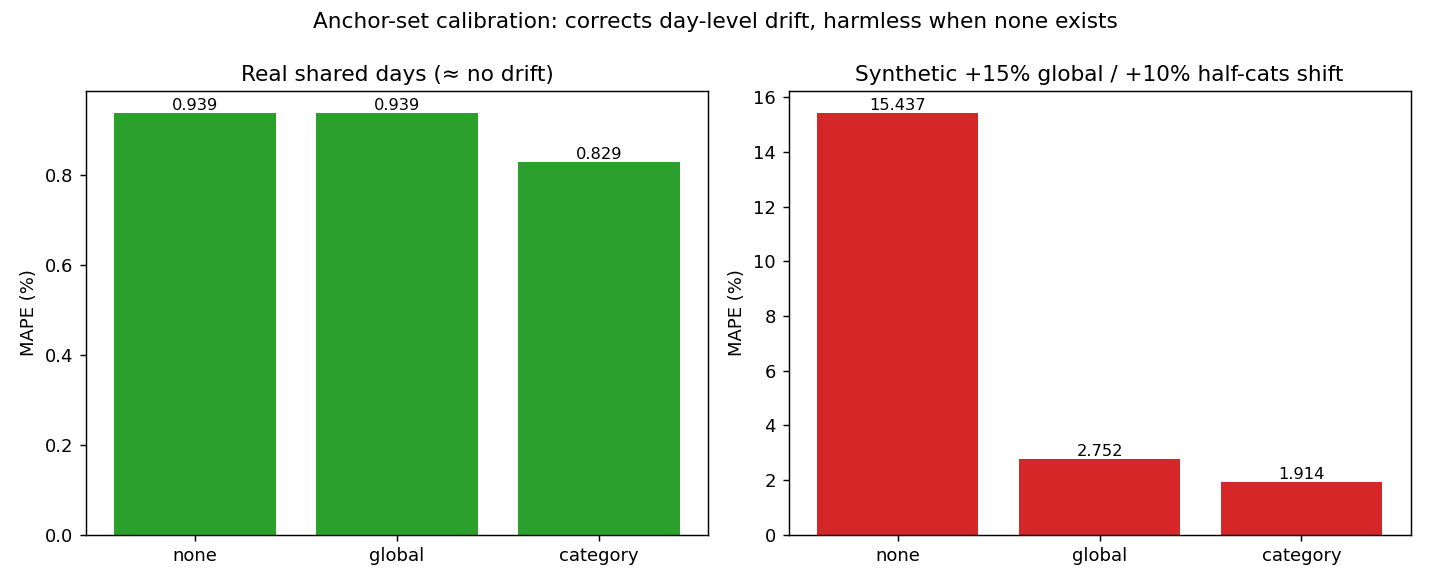

In [6]:
Image(str(REPORTS / 'fig_calibration.png'))

## 4. Feature importance (Tier 1 global model, SHAP)

In [7]:
shap = load('shap_global.json')
pd.DataFrame(shap).head(12)

,feature,mean_abs_shap
0,log_last_price,0.037273
1,log_median_price,0.033849
2,last_price,0.032610
3,median_price,0.019979
4,shopId,0.004423
5,shop_n_obs,0.003305
6,modelId__mean_price,0.003064
7,item_n_obs,0.002907
8,model_n_obs,0.002830
9,cat_id,0.002621


The leak-safe Tier 1 model leans on `log_last_price`, `log_median_price`, `last_price`, and shop/category signals — confirming it is mostly learning corrections around the LOCF baseline.

## Conclusion

- **Tier 2 wins**: price is entity-specific; product history beats a marketplace-wide model when history exists.
- **Tier 1 is now leakage-safe**: CatBoost training features are built with strict pre-day entity statistics.
- **The anchor set is the only same-day signal** and is what makes the system robust to outage-day promotions / currency shifts.
- **Production recommendation**: hierarchical LOCF base + per-category anchor calibration.